In [16]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Autocorrelation model (Eq. 3-4, exact equation)
# ---------------------------------------------------------
def G_exact(tau, k, c, N, M):
    tau = np.asarray(tau, dtype=float)
    n1 = np.arange(0, N + 1)
    n3 = np.arange(N, M + 1)
    n4 = np.arange(1, N + 1)
    n5 = np.arange(0, M + 1)

    kt = np.outer(k * tau, np.ones_like(n1, dtype=float))  # placeholder shape
    def poch(kt_vec, n):
        # (k*tau)^n / n! per term, summed over n, kt_vec: array of tau
        out = np.zeros_like(kt_vec, dtype=float)
        for nn in n:
            out += (k * kt_vec) ** nn / np.math.factorial(int(nn))
        return out

    G1 = np.zeros_like(tau)
    for n in n1:
        G1 += (N - n) * (N - n + 1) * (2 * N + n + 1) / 6 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))

        #  term1 = c / k * np.exp(-k * x) * sum(
        # (N - n) * (N - n + 1) * (((2 * N) + n + 1) / 6) * (
        #             ((k * x) ** n) / np.float128(factorial(n))) for n in
        # range(0, int(N)))

    G2 = np.zeros_like(tau)
    for n in n1:
        G2 += N * n * (2 * N - n + 1) / 2 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))

    G3 = np.zeros_like(tau)
    for n in n3:
        G3 += N**2 * (N + 1) / 2 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))

    G4 = np.zeros_like(tau)
    for n in n4:
        exp_ = M + N - n
        if exp_ >= 0:
            G4 += N * n * (1 + n) / 2 * (k * tau) ** exp_ / np.float128(np.math.factorial(int(exp_)))

    G5 = np.zeros_like(tau)
    for n in n5:
        G5 += N**2 * (M - n) * (k * tau) ** n / np.float128(np.math.factorial(int(n)))

    prefactor = k * np.exp(-k * tau) / (c * (N * (N + 1) / 2 + N * M) ** 2)
    return prefactor * (G1 + G2 + G3 + G4 + G5)


# ---------------------------------------------------------
# 2. Simulate one polysome fluorescence track (Eq. 1-2)
# ---------------------------------------------------------
def phi_single(t_rel, chi_s, chi_p, k, N, theta):
    """Fluorescence contribution of a ribosome initiated at t=0, evaluated at t_rel."""
    out = np.zeros_like(t_rel)
    ramp = (t_rel >= 0) & (t_rel < chi_s / k)
    plateau = (t_rel >= chi_s / k) & (t_rel < chi_p / k)
    out[ramp] = (N * theta * k / chi_s) * t_rel[ramp]
    out[plateau] = N * theta
    return out


def simulate_track(k, c, chi_s, chi_p, N, theta, T_total, dt_fine, rng):
    """Generate a fine-resolution track, sum contributions of all initiated ribosomes."""
    t_grid = np.arange(0, T_total, dt_fine)
    I = np.zeros_like(t_grid)

    # Poisson initiation times over [0, T_total], with margin for tail ribosomes
    n_expected = c * T_total
    n_init = rng.poisson(n_expected * 1.5)
    init_times = np.sort(rng.uniform(0, T_total, n_init))

    for t0 in init_times:
        t_rel = t_grid - t0
        mask = (t_rel >= 0) & (t_rel < chi_p / k)
        if mask.any():
            I[mask] += phi_single(t_rel[mask], chi_s, chi_p, k, N, theta)

    return t_grid, I


# ---------------------------------------------------------
# 3. Empirical autocorrelation from a (sub)sampled track
# ---------------------------------------------------------
def empirical_autocorr(I, dt, max_lag_frac=0.5):
    I = I - np.mean(I)
    n = len(I)
    max_lag = int(n * max_lag_frac)
    var = np.mean(I**2)
    G = np.array([np.mean(I[:n - lag] * I[lag:]) for lag in range(1, max_lag)]) / var
    tau = np.arange(1, max_lag) * dt
    return tau, G


# ---------------------------------------------------------
# 4. Fit k, c from a track
# ---------------------------------------------------------
def fit_track(tau, G, N, M, k_guess, c_guess):
    model = lambda tau, k, c: G_exact(tau, k, c, N, M)
    if (np.isnan(G).any()):
        return [np.nan, np.nan]
    try:
        popt, _ = curve_fit(model, tau, G, p0=[k_guess, c_guess],
                             bounds=([1e-4, 1e-4], [np.inf, np.inf]), maxfev=5000)
        return popt
    except RuntimeError:
        return [np.nan, np.nan]


# ---------------------------------------------------------
# 5. Sweep: track length (fixed dt)
# ---------------------------------------------------------
def sweep_track_length(k_true, c_true, chi_s, chi_p, N, M, theta,
                        T_list, dt, n_repeats=10, dt_fine=0.1, seed=0):
    rng = np.random.default_rng(seed)
    tau_c = (chi_s + chi_p) / k_true
    results = []

    T_max = max(T_list)
    for T in T_list:
        errors = []
        for _ in range(n_repeats):
            t_grid, I_fine = simulate_track(k_true, c_true, chi_s, chi_p, N, theta,
                                             T_max, dt_fine, rng)
            step = int(round(dt / dt_fine))
            I_ds = I_fine[::step]
            n_pts = int(T / dt)
            I_track = I_ds[:n_pts]
            if len(I_track) < 10:
                continue
            tau, G = empirical_autocorr(I_track, dt)
            k_fit, c_fit = fit_track(tau, G, N, M, k_true, c_true)
            if not np.isnan(k_fit):
                errors.append(abs(k_fit - k_true) / k_true)
        results.append((T / tau_c, np.nanmean(errors), np.nanstd(errors)))
    return np.array(results)


# ---------------------------------------------------------
# 6. Sweep: dt (fixed track length)
# ---------------------------------------------------------
def sweep_dt(k_true, c_true, chi_s, chi_p, N, M, theta,
             dt_list, T_fixed, n_repeats=10, dt_fine=0.1, seed=1):
    rng = np.random.default_rng(seed)
    results = []

    for dt in dt_list:
        errors = []
        for _ in range(n_repeats):
            t_grid, I_fine = simulate_track(k_true, c_true, chi_s, chi_p, N, theta,
                                             T_fixed, dt_fine, rng)
            step = max(1, int(round(dt / dt_fine)))
            I_ds = I_fine[::step]
            if len(I_ds) < 10:
                continue
            tau, G = empirical_autocorr(I_ds, dt)
            k_fit, c_fit = fit_track(tau, G, N, M, k_true, c_true)
            if not np.isnan(k_fit):
                errors.append(abs(k_fit - k_true) / k_true)
        results.append((dt * k_true / chi_s, np.nanmean(errors), np.nanstd(errors)))
    return np.array(results)




/tmp/ipykernel_23774/3231311487.py:25: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  G1 += (N - n) * (N - n + 1) * (2 * N + n + 1) / 6 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))
/tmp/ipykernel_23774/3231311487.py:34: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  G2 += N * n * (2 * N - n + 1) / 2 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))
/tmp/ipykernel_23774/3231311487.py:38: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  G3 += N**2 * (N + 1) / 2 * (k * tau) ** n / np.float128(np.math.factorial(int(n)))
/tmp/ipykernel_23774/3231311487.py:44: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` mod

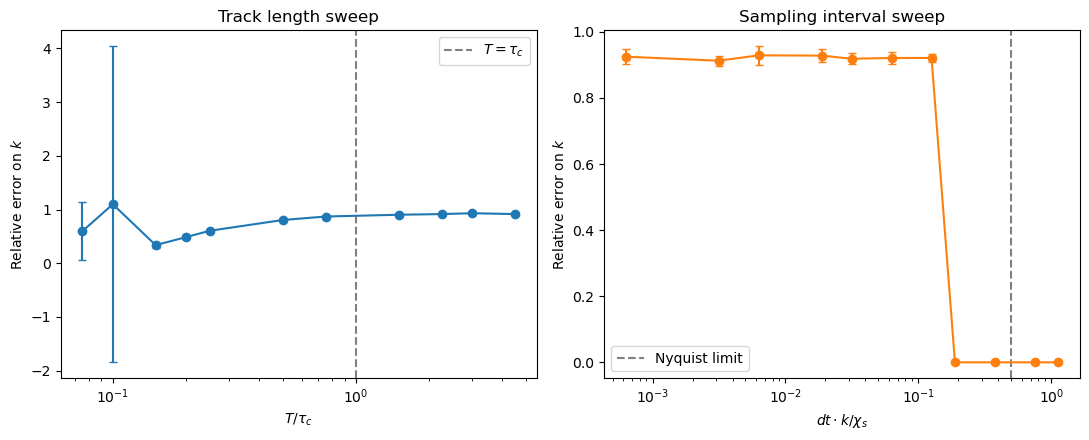

In [26]:
# ---------------------------------------------------------
# 7. Run sweeps and plot
# ---------------------------------------------------------
if __name__ == "__main__":
    # Model parameters (match paper's Fig. 4 example)
    k_true, c_true = 5.0, 0.05      # aa/sec, ribosome/sec
    chi_s, chi_p = 796, 1200        # aa
    N, M = 32, int(chi_p / (chi_s / 32))
    theta = 1.0

    T_list = np.array([30,40,60, 80, 100,200, 300, 600,900, 1200, 1800,])# 3600])
    dt_fixed = 1.0
    res_T = sweep_track_length(k_true, c_true, chi_s, chi_p, N, M, theta,
                                T_list, dt_fixed, n_repeats=15)

    dt_list = np.array([0.1, 0.5, 1, 3, 5, 10, 20, 30, 60, 120, 180])
    T_fixed = 1800
    res_dt = sweep_dt(k_true, c_true, chi_s, chi_p, N, M, theta,
                       dt_list, T_fixed, n_repeats=15)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].errorbar(res_T[:, 0], res_T[:, 1], yerr=res_T[:, 2],
                      marker='o', capsize=3)
    axes[0].axvline(1, color='gray', linestyle='--', label=r'$T=\tau_c$')
    axes[0].set_xscale('log')
    axes[0].set_xlabel(r'$T / \tau_c$')
    axes[0].set_ylabel('Relative error on $k$')
    axes[0].set_title('Track length sweep')
    axes[0].legend()

    axes[1].errorbar(res_dt[:, 0], res_dt[:, 1], yerr=res_dt[:, 2],
                      marker='o', color='tab:orange', capsize=3)
    axes[1].axvline(0.5, color='gray', linestyle='--', label=r'Nyquist limit')
    axes[1].set_xscale('log')
    axes[1].set_xlabel(r'$dt \cdot k / \chi_s$')
    axes[1].set_ylabel('Relative error on $k$')
    axes[1].set_title('Sampling interval sweep')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [13]:
%pdb

Automatic pdb calling has been turned ON


In [27]:
def recommend_acquisition(k_est, chi_s, chi_p, n_transit=7, samples_per_ramp=3):
    """
    Recommend track length (T) and sampling interval (dt) given estimated
    elongation rate and construct geometry.

    k_est: estimated elongation rate (aa/sec)
    chi_s: stem-loop length (aa)
    chi_p: protein length (aa)
    n_transit: number of transit times to include in track (default 5-10 range, using 7)
    samples_per_ramp: number of samples desired across the stem-loop ramp phase (2-4 typical)
    """
    tau_c = (chi_s + chi_p) / k_est          # full transit time
    tau_ramp = chi_s / k_est                  # stem-loop ramp time

    T_recommended = n_transit * tau_c
    dt_recommended = tau_ramp / samples_per_ramp
    dt_nyquist_limit = tau_ramp / 2           # hard upper bound, do not exceed

    n_points = int(T_recommended / dt_recommended)

    return {
        "tau_c (transit time, sec)": tau_c,
        "tau_ramp (stem-loop ramp time, sec)": tau_ramp,
        "recommended track length T (sec)": T_recommended,
        "recommended dt (sec)": dt_recommended,
        "hard Nyquist limit on dt (sec, do not exceed)": dt_nyquist_limit,
        "resulting number of frames": n_points,
    }


# Example: using estimated k=5 aa/sec, chi_s=796aa, chi_p=1200aa
result = recommend_acquisition(k_est=5.0, chi_s=796, chi_p=1200)
for key, val in result.items():
    print(f"{key}: {val:.2f}" if isinstance(val, float) else f"{key}: {val}")

tau_c (transit time, sec): 399.20
tau_ramp (stem-loop ramp time, sec): 159.20
recommended track length T (sec): 2794.40
recommended dt (sec): 53.07
hard Nyquist limit on dt (sec, do not exceed): 79.60
resulting number of frames: 52
